In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
netflix=pd.read_csv("C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\data\\netflix_cleaned.csv")

In [3]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [4]:
netflix['date_added']=pd.to_datetime(netflix['date_added'].str.strip())

In [5]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'added_year'],
      dtype='str')

In [6]:
netflix['added_year'].unique()

array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
       2009, 2008, 2010])

In [7]:
netflix.groupby('added_year').agg({'title':'nunique'})

,title
added_year,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


In [8]:
type_by_year=pd.get_dummies(netflix,columns=['type'],dtype=int).groupby('added_year').agg({
    'type_Movie':'sum',
'type_TV Show':'sum'
})
type_by_year

,type_Movie,type_TV Show
added_year,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,5
2014,19,5
2015,56,26
2016,253,176


In [9]:
type_proportion=type_by_year.div(type_by_year.sum(axis=1),axis=0)*100
type_proportion

,type_Movie,type_TV Show
added_year,,
2008,50.000000,50.000000
2009,100.000000,0.000000
2010,100.000000,0.000000
2011,100.000000,0.000000
2012,100.000000,0.000000
2013,54.545455,45.454545
2014,79.166667,20.833333
2015,68.292683,31.707317
2016,58.974359,41.025641


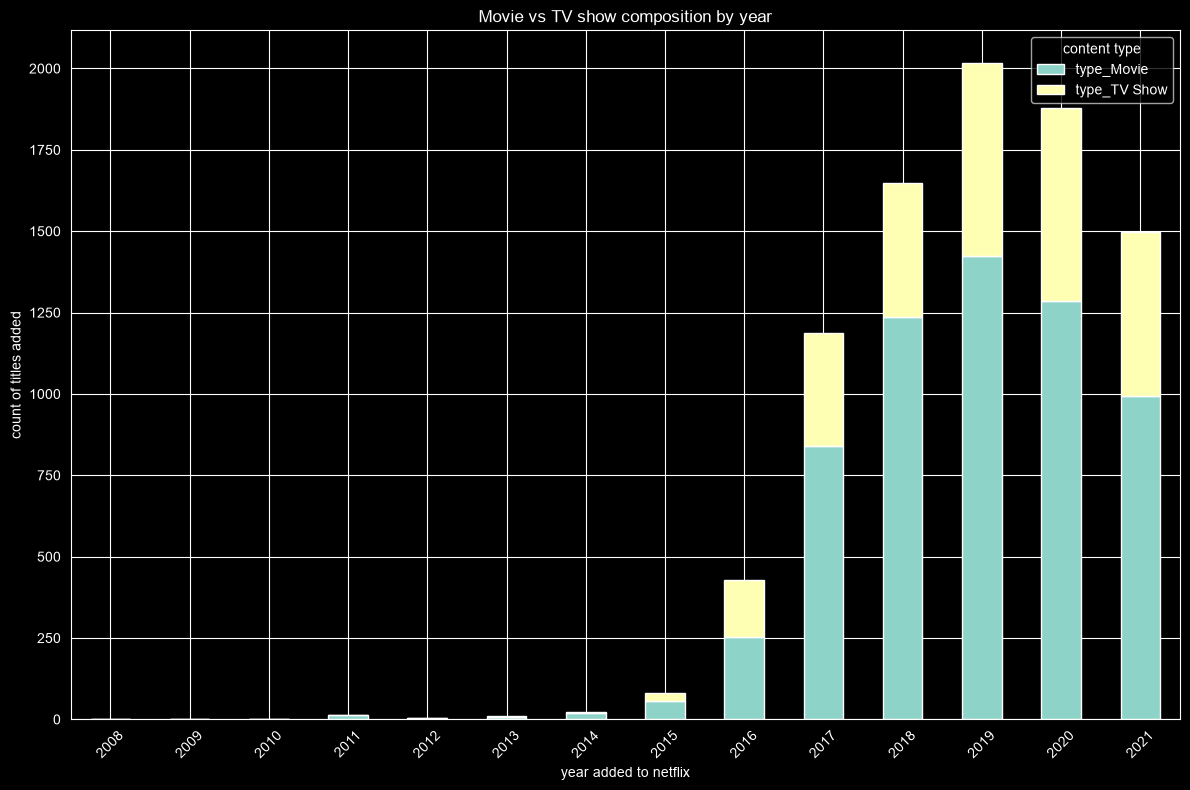

In [10]:
type_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(12,8)
)
plt.title('Movie vs TV show composition by year')
plt.xlabel('year added to netflix')
plt.ylabel('count of titles added')
plt.legend(title='content type')
plt.xticks(rotation=45)
plt.tight_layout()

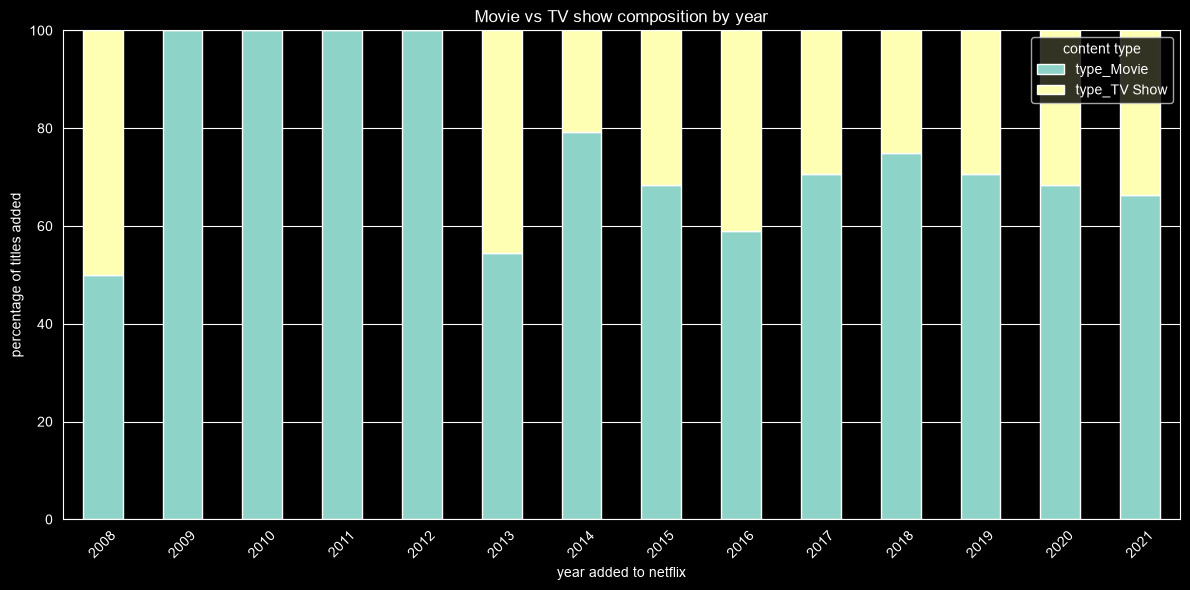

In [11]:
type_proportion.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Movie vs TV show composition by year')
plt.xlabel('year added to netflix')
plt.ylabel('percentage of titles added')
plt.legend(title='content type')
plt.xticks(rotation=45)
plt.tight_layout()

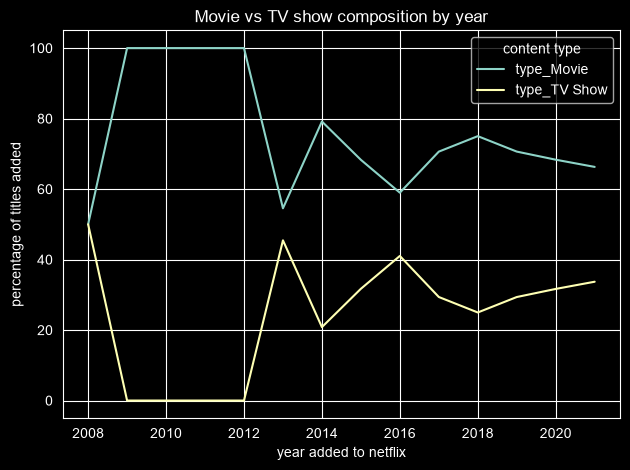

In [12]:
type_proportion.plot(
    y=[
        'type_Movie','type_TV Show'
    ]
)
plt.title('Movie vs TV show composition by year')
plt.xlabel('year added to netflix')
plt.ylabel('percentage of titles added')
plt.legend(title='content type')
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\movies_vs_tv_shows.png',dpi=300,bbox_inches='tight')